# Proyecto en dataset de ventas
Este proyecto tiene la misión de analizar las ventas del dataset descargado a partir de https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting.   
El analisis está enfocado en el descubrimiento de tendencias, patrones que puedan ser de beneficio para la toma de decisiones de la superstore.

### 1. Importaciones

Primero agregar raíz del proyecto para que funcione la búsqueda de funciones en otras carpetas. Primero con Path("..") va una ruta hacia atrás, con resolve toma esa ruta y la hace completa, no solo relativa (hace la ruta completa del sistema), luego agrega esa ruta en los sys.path si es que ya no está y la agrega al principio.

In [1]:
import sys
from pathlib import Path
root = str(Path("..").resolve())
if root not in sys.path:
    sys.path.insert(0, root)

Luego si hacer todas las importaciones necesarias

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import create_subcategory_count, create_region_total_sale, create_region_count, create_mon_and_tot_sale, create_st_and_to_sale, create_state_count
from src.data_cleaning import clean_na_transform_date
#from src.visualization import create_fig_subca_count, create_fig_re_to_sa, create_fig_region_count, create_m_and_ts, create_fig_st_and_to_sale, create_fig_state_count, create_fig_st_and_to_sale_pie

In [3]:
%matplotlib inline

### 2. Carga de los datos

In [5]:
# Sube 1 nivel desde el notebook y luego va a lo siguiente de la ruta
ruta = r'..\data\raw\train.csv'
df = pd.read_csv(ruta)

### 3. Ver información inicial de los datos

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [8]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### 4. Limpieza de datos y transformaciones


#### 4.1 Postal Code nulls

Veamos si tiene demasiados códigos postales diferentes. Veremos que tiene 626 así que de momento lo dejaremos.

In [9]:
df['Postal Code'].nunique()

626

#### 4.2 Dates format

Los features de fechas son str así que lo cambiaremos a datetime.

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

#### 4.3 ID's

Los ID's difícilmente van a proporcionarnos información valiosa, asi que los quitaremos.

In [11]:
df = df.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Product ID'])

#### 4.4 Product name

El nombre del producto es una serie con demasiadas categorías, por lo que dificilmente pueda indicarnos algo valioso en las ventas.

In [12]:
df = df.drop(columns=['Product Name'])

#### 4.5 Postal Code

El código postal probablemente venga condicionado por country, city y state, asi que veremos si vale la pena eliminarlo por redundancia.

In [13]:
df.groupby(['Country', 'City', 'State'])['Postal Code'].nunique()

Country        City         State       
United States  Aberdeen     South Dakota    1
               Abilene      Texas           1
               Akron        Ohio            1
               Albuquerque  New Mexico      1
               Alexandria   Virginia        1
                                           ..
               Woonsocket   Rhode Island    1
               Yonkers      New York        1
               York         Pennsylvania    1
               Yucaipa      California      1
               Yuma         Arizona         1
Name: Postal Code, Length: 600, dtype: int64

In [14]:
df.groupby(['Country', 'City', 'State'])['Postal Code'].nunique().describe()

count    600.000000
mean       1.045000
std        0.364962
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        6.000000
Name: Postal Code, dtype: float64

Al menos el 75% de las combinaciónes de Country, City y State tienen solo 1 Postal Code, asi que si viene condicionado, por lo que lo eliminamos.

In [15]:
df = df.drop(columns=['Postal Code'])

#### 4.6 Ordenar dataframe por fecha

In [16]:
df = df.sort_values(by='Order Date').reset_index()

In [17]:
df.drop(columns=['index'], inplace=True)

#### 4.7 Order Date as a Index

Colocamos la columna Order Date como el índice, para poder hacer operaciones de tiempo.

In [18]:
df = df.set_index(df['Order Date'])

In [19]:
df.drop(columns=['Order Date'], inplace=True)

#### 4.8 Customer Name

El nombre del cliente también dificilmente tiene alguna relación con el target, además, tenemos muchas categorías diferentes como para identificar tendencia.

In [20]:
df['Customer Name'].nunique()

793

In [21]:
df.drop(columns=['Customer Name'], inplace=True)

#### 5. Visualizations

In [22]:
df.head(2)

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540


#### 5.1 Sales a través del tiempo

Totales de ventas cada mes

Text(0.5, 1.0, 'Total sales by month')

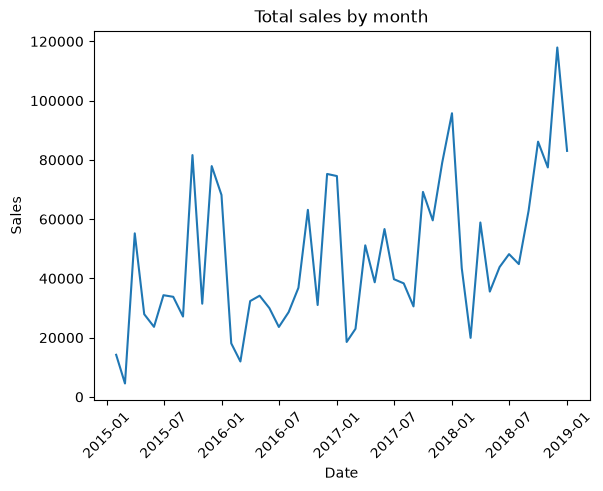

In [23]:
# Se samplean las ventas por ME (mes) del índice

plt.plot(
    df['Sales'].resample('ME').sum()
)

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Total sales by month')

#### 5.2 Distribution of sales

Veremos como los datos están completamente sesgados, con casi todas las ventas por debajo de los 2,500

<Axes: xlabel='Sales', ylabel='Count'>

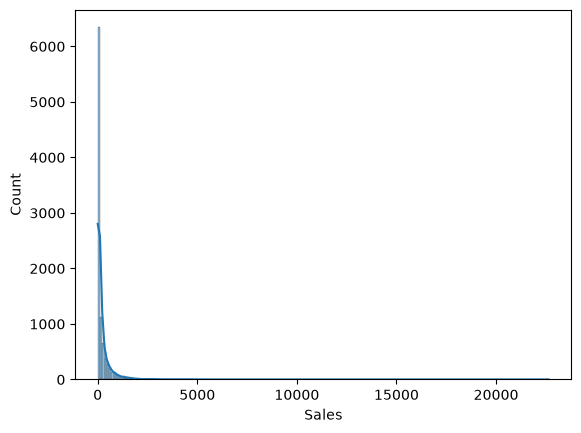

In [32]:
sns.histplot(
    data=df,
    x='Sales',
    kde=True
)

#### 5.3 Ship Mode sales

Text(0.5, 1.0, 'Sales by Ship Mode')

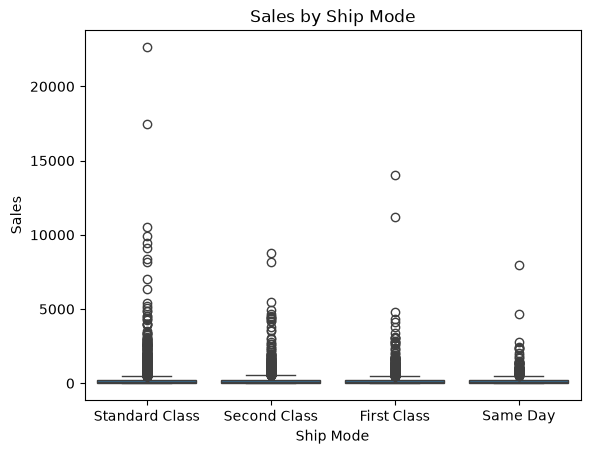

In [26]:
sns.boxplot(
    data=df,
    x='Ship Mode',
    y='Sales'
)

plt.title('Sales by Ship Mode')

<Axes: xlabel='Sales', ylabel='Count'>

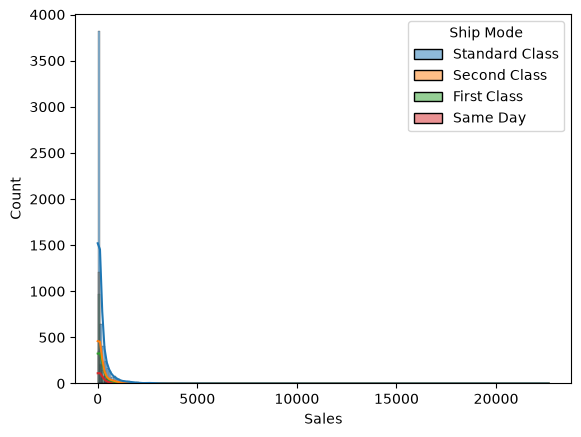

In [33]:
sns.histplot(
    data=df,
    x='Sales',
    hue='Ship Mode',
    kde=True
)

#### 5.4 Segment sales

Text(0.5, 1.0, 'Sales by Segment')

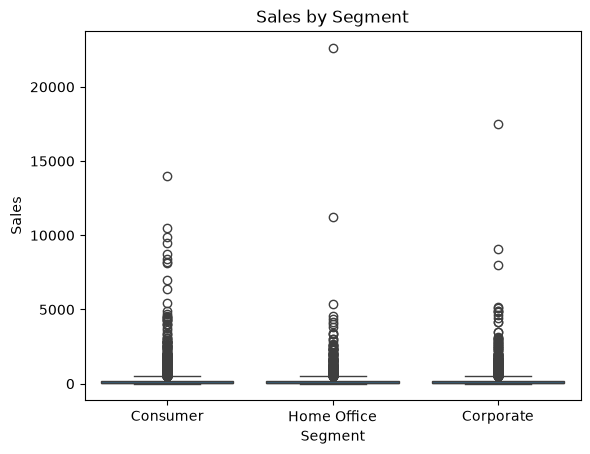

In [29]:
sns.boxplot(
    data=df,
    x='Segment',
    y='Sales'
)

plt.title('Sales by Segment')

#### 5.5 Country sales

Todas las ventas fueron hechas solo en estados unidos.

Text(0.5, 1.0, 'Sales by country')

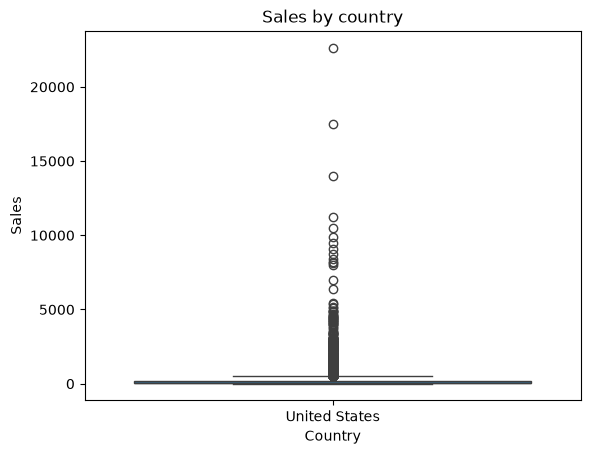

In [40]:
sns.boxplot(
    data=df,
    x='Country',
    y='Sales'
)

plt.title('Sales by country')

#### 5.6 City sales

El feature city tiene muchas categorías posibles así que lo mejor que haremos en este caso es saber cuales son las que proporcionar mayores ganancias.

In [43]:
df['City'].nunique()

529

<Axes: xlabel='City', ylabel='Sales'>

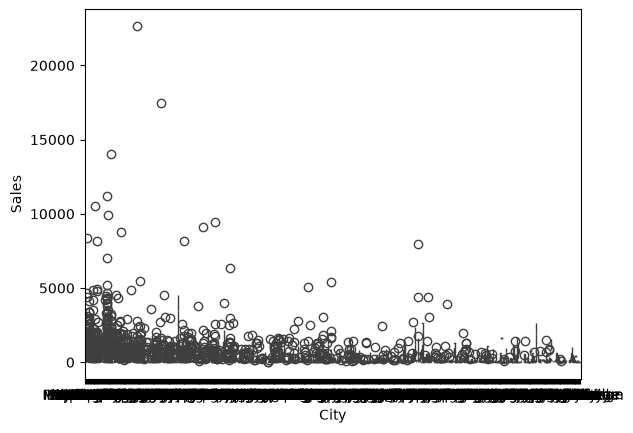

In [39]:
sns.boxplot(
    data=df,
    x='City',
    y='Sales'
)

Agrupar por city (top 10 promedio de ventas)

In [45]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


In [51]:
group_city_top_10_sales = df.groupby('City')['Sales'].mean().sort_values(ascending=False).head(10)
names_top_10_cities = group_city_top_10_sales.index
names_top_10_cities

Index(['Jamestown', 'Cheyenne', 'Bellingham', 'Independence', 'Burbank',
       'Buffalo', 'Burlington', 'Beverly', 'Lafayette', 'Sparks'],
      dtype='str', name='City')

Obtener solo los registros en donde City esté dentro del top.

In [52]:
df_top10_city = df[df['City'].isin(names_top_10_cities)]

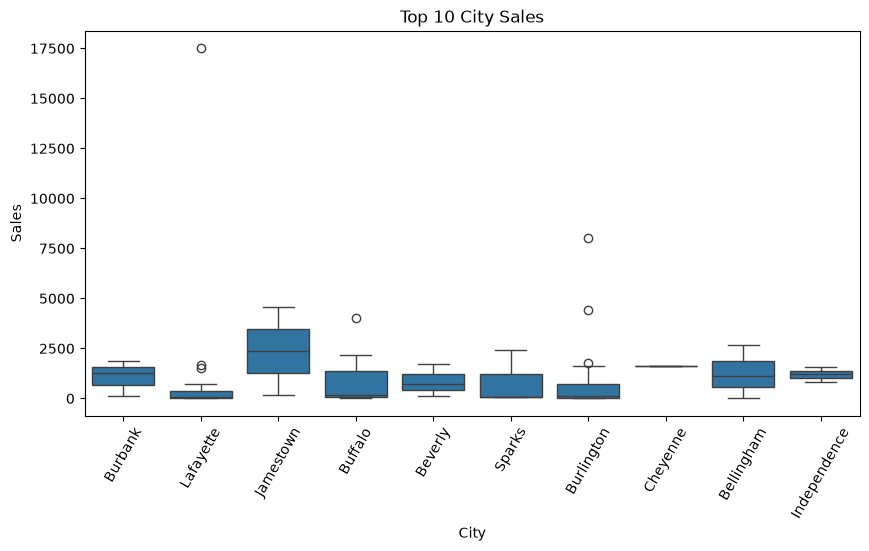

In [63]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_top10_city,
    x='City',
    y='Sales'
)

plt.title('Top 10 City Sales')

plt.xticks(rotation=60)
plt.show()

#### 5.7 State sales

Text(0.5, 1.0, 'Sales by State')

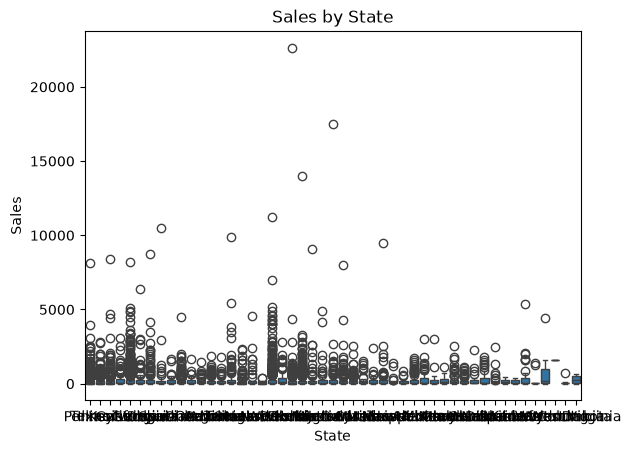

In [64]:
sns.boxplot(
    data=df,
    x='State',
    y='Sales'
)

plt.title('Sales by State')

Agrupar por State (top 10 promedio de ventas)

In [65]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


In [66]:
group_state_top_10_sales = df.groupby('State')['Sales'].mean().sort_values(ascending=False).head(10)
names_top_10_states = group_state_top_10_sales.index
names_top_10_states

Index(['Wyoming', 'Vermont', 'Nevada', 'Rhode Island', 'Montana', 'Indiana',
       'Missouri', 'Minnesota', 'Alabama', 'Virginia'],
      dtype='str', name='State')

Obtener solo los registros en donde State esté dentro del top.

In [67]:
df_top10_state = df[df['State'].isin(names_top_10_states)]

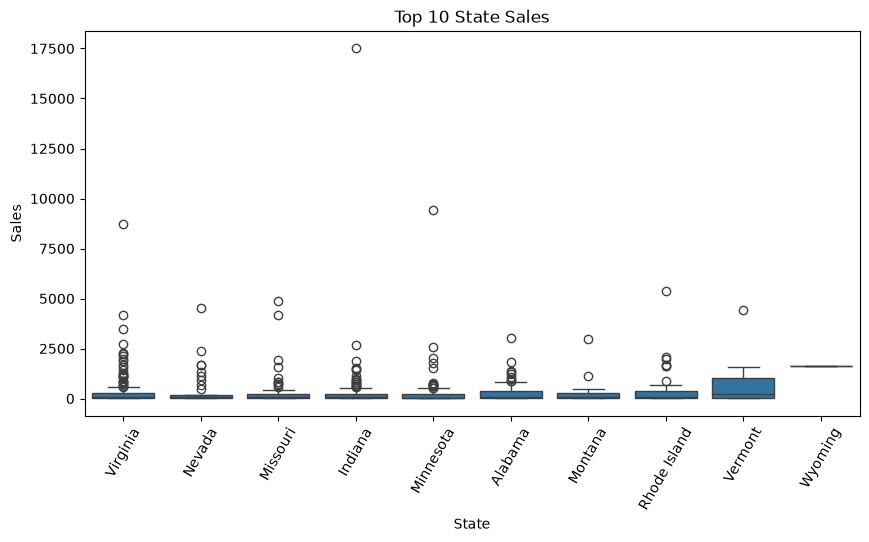

In [68]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_top10_state,
    x='State',
    y='Sales'
)

plt.title('Top 10 State Sales')

plt.xticks(rotation=60)
plt.show()

#### 5.9 Sales by Region

In [69]:
df.head()

,Ship Date,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category,Sales
Order Date,,,,,,,,,,
2015-01-03,2015-01-03,Standard Class,Consumer,United States,Houston,Texas,Central,Office Supplies,Paper,16.448
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Binders,3.540
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Storage,272.736
2015-01-04,2015-01-04,Standard Class,Home Office,United States,Naperville,Illinois,Central,Office Supplies,Labels,11.784
2015-01-05,2015-01-05,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,East,Office Supplies,Art,19.536


<Axes: xlabel='Region', ylabel='Sales'>

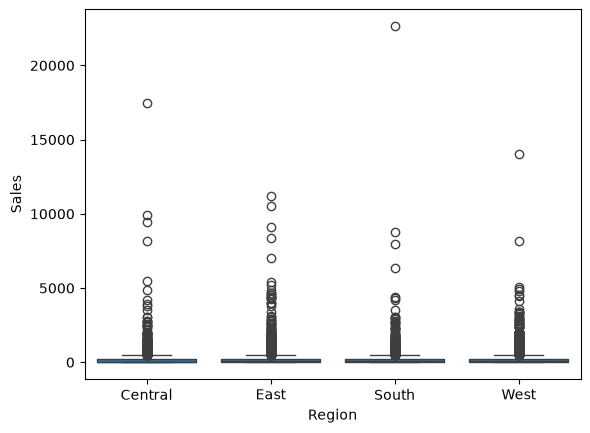

In [70]:
sns.boxplot(
    data=df,
    x='Region',
    y='Sales'
)

### Guardar la información en processed

In [ ]:
df_sin_nulos.to_csv('../data/processed/train_clean.csv')

### Crear datos necesarios y sus gráficos
1. En primer lugar lo que se hace es un DataFrame para poder manejar la cantidad de veces que se repite una sub-categoria, pudiendo saber cual es la categoria que mas se compra

In [ ]:
df_sub_category_count = create_subcategory_count(df_sin_nulos)
print(f'\n\nSub-category count:\n{df_sub_category_count}')

fig_sub_category_count = create_fig_subca_count(df_sub_category_count)


2. DataFrame para poder controlar cuanto ha vendido en total cada región

In [ ]:
df_region_total_sale = create_region_total_sale(df_sin_nulos)
print(f'\n\nRegiones con su venta total:\n{df_region_total_sale}')

fig_region_total_sale = create_fig_re_to_sa(df_region_total_sale)

3. DataFrame para contar cuantas ventas se han hecho en cada region

In [ ]:
df_region_count = create_region_count(df_sin_nulos)

print(f'Cantidad de ventas por cada region:\n{df_region_count}')

fig_region_count = create_fig_region_count(df_region_count)


4. DataFrame para ver las ventas totales de cada mes

In [ ]:
df_months_and_total_sale = create_mon_and_tot_sale(df_sin_nulos)

print(f'Fecha por mes y su venta total\n{df_months_and_total_sale}')

fig_months_total_sale = create_m_and_ts(df_months_and_total_sale)


5. DataFrame para ver ventas totales de cada estado en gráfico de barras y pie

In [ ]:
df_state_and_total_sale = create_st_and_to_sale(df_sin_nulos)

print(f'Ventas totales por cada estado:\n{df_state_and_total_sale}')

fig_state_and_total_sale = create_fig_st_and_to_sale(df_state_and_total_sale)

fig_state_and_total_sale_pie = create_fig_st_and_to_sale_pie(df_state_and_total_sale)


6. DataFrame para ver cantidad de ventas de cada estado

In [ ]:
df_state_count = create_state_count(df_sin_nulos)

print(f'Cantidad de ventas por cada estado:\n{df_state_count}')

fig_state_count = create_fig_state_count(df_state_count)

### Mostrar los gráficos de plotly
Estos gráficos estan configurados para mostrarse en el navegador gracias a "pio"    
Orden de los gráficos:  
1. Sub-category/Count  
2. Region/Sales    
3. Region/Count    
4. Order Date/Sales    
5. State/Sales (Bar)
6. State/Sales (Pie)
7. State/Count 

In [ ]:
fig_sub_category_count.show()
fig_region_total_sale.show()
fig_region_count.show()
fig_months_total_sale.show()
fig_state_and_total_sale.show()
fig_state_and_total_sale_pie.show()
fig_state_count.show()

### Guardar cada gráfico dentro de los outputs

In [ ]:
fig_sub_category_count.write_image('../outputs/figures/sub_category_count.png')
fig_region_total_sale.write_image('../outputs/figures/region_and_total_sale.png')
fig_region_count.write_image('../outputs/figures/region_count.png')
fig_months_total_sale.write_image('../outputs/figures/months_total_sale.png')
fig_state_and_total_sale.write_image('../outputs/figures/state_and_total_sale.png')
fig_state_and_total_sale_pie.write_image('../outputs/figures/state_and_total_sale_pie.png')
fig_state_count.write_image('../outputs/figures/state_count.png')